In [115]:
#TODO: Explore nulls in country
#TODO: Explore month x week cancellation rate



In [116]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

plt.rcParams['figure.figsize'] = (12, 8)
sns.set_palette('viridis')
sns.set_context('notebook')

df_default = pd.read_csv('../data/hotel_bookings.csv')
display(df_default.shape)
df_default.describe(include='all')

(119390, 32)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
count,119390,119390.000000,119390.000000,119390.000000,119390,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,...,119390,103050.000000,6797.000000,119390.000000,119390,119390.000000,119390.000000,119390.000000,119390,119390
unique,2,NaN,NaN,NaN,12,NaN,NaN,NaN,NaN,NaN,...,3,NaN,NaN,NaN,4,NaN,NaN,NaN,3,926
top,City Hotel,NaN,NaN,NaN,August,NaN,NaN,NaN,NaN,NaN,...,No Deposit,NaN,NaN,NaN,Transient,NaN,NaN,NaN,Check-Out,2015-10-21
freq,79330,NaN,NaN,NaN,13877,NaN,NaN,NaN,NaN,NaN,...,104641,NaN,NaN,NaN,89613,NaN,NaN,NaN,75166,1461
mean,NaN,0.370416,104.011416,2016.156554,NaN,27.165173,15.798241,0.927599,2.500302,1.856403,...,NaN,86.693382,189.266735,2.321149,NaN,101.831122,0.062518,0.571363,NaN,NaN
std,NaN,0.482918,106.863097,0.707476,NaN,13.605138,8.780829,0.998613,1.908286,0.579261,...,NaN,110.774548,131.655015,17.594721,NaN,50.535790,0.245291,0.792798,NaN,NaN
min,NaN,0.000000,0.000000,2015.000000,NaN,1.000000,1.000000,0.000000,0.000000,0.000000,...,NaN,1.000000,6.000000,0.000000,NaN,-6.380000,0.000000,0.000000,NaN,NaN
25%,NaN,0.000000,18.000000,2016.000000,NaN,16.000000,8.000000,0.000000,1.000000,2.000000,...,NaN,9.000000,62.000000,0.000000,NaN,69.290000,0.000000,0.000000,NaN,NaN
50%,NaN,0.000000,69.000000,2016.000000,NaN,28.000000,16.000000,1.000000,2.000000,2.000000,...,NaN,14.000000,179.000000,0.000000,NaN,94.575000,0.000000,0.000000,NaN,NaN
75%,NaN,1.000000,160.000000,2017.000000,NaN,38.000000,23.000000,2.000000,3.000000,2.000000,...,NaN,229.000000,270.000000,0.000000,NaN,126.000000,0.000000,1.000000,NaN,NaN


In [117]:
df_default.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [118]:
#printing share of null values per column
share_nulls = {}
n_rows = len(df_default)
for colname in df_default.columns:
    nulls_pctng = df_default[colname].isnull().sum()/n_rows*100
    if nulls_pctng>0:
        share_nulls[colname] = nulls_pctng

for colname,share_of_nulls in share_nulls.items():
     print(f'Column {colname} has null share of {share_nulls[colname]:.2f}%')

Column children has null share of 0.00%
Column country has null share of 0.41%
Column agent has null share of 13.69%
Column company has null share of 94.31%


In [119]:
df_default.children = df_default.children.fillna(0) #we assume na children = no children

df_default.country = df_default.country.fillna('Unknown') #swapping na country to "Unknown"

df_default.company = df_default.company.fillna('Unknown') #swapping na company to "Unknown"

df_default["arrival_date"] = pd.to_datetime(
    df_default["arrival_date_year"].astype(str) + " " +
    df_default["arrival_date_month"] + " " +
    df_default["arrival_date_day_of_month"].astype(str)) #constructing arrival date variable in YYYY-MM-DD format

df_default["arrival_date_year"] = df_default["arrival_date_year"].astype(int)

import calendar
month_order = list(calendar.month_name)[1:]
df_default['arrival_date_month'] = pd.Categorical(df_default['arrival_date_month'], categories=month_order, ordered=True)
df_default.sort_values('arrival_date', inplace=True)

df_default.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,arrival_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,NaN,Unknown,0,Transient,0.0,0,0,Check-Out,2015-07-01,2015-07-01
75559,City Hotel,0,257,2015,July,27,1,0,2,1,...,6.0,Unknown,0,Transient,80.0,0,0,Check-Out,2015-07-03,2015-07-01
75560,City Hotel,0,257,2015,July,27,1,0,2,2,...,6.0,Unknown,0,Transient,101.5,0,0,Check-Out,2015-07-03,2015-07-01
75561,City Hotel,0,257,2015,July,27,1,0,2,2,...,6.0,Unknown,0,Transient,101.5,0,0,Check-Out,2015-07-03,2015-07-01
75562,City Hotel,0,257,2015,July,27,1,0,2,2,...,6.0,Unknown,0,Transient,101.5,0,0,Check-Out,2015-07-03,2015-07-01


In [120]:
#reformatting column names for ease of use
for column in df_default.columns:
    df_default.rename(columns={column: column.replace('_', ' ').title().replace(' ', '')}, inplace=True)

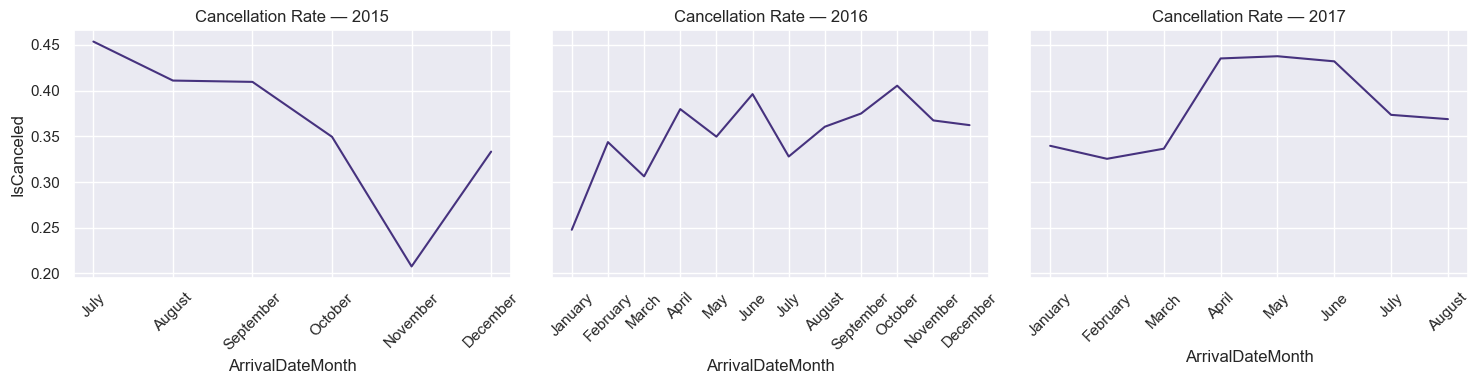

In [121]:
years = sorted(df_default.ArrivalDateYear.unique())

fig, axes = plt.subplots(1, len(years), figsize=(5 * len(years), 4), sharey=True)
for ax, year in zip(axes, years):
    by_month = (
        df_default[df_default.ArrivalDateYear == year]
        .groupby('ArrivalDateMonth')['IsCanceled']
        .mean()
        .reset_index()
    )

    sns.lineplot(data=by_month, x='ArrivalDateMonth', y='IsCanceled', ax=ax)
    ax.set_title(f'Cancellation Rate — {year}')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

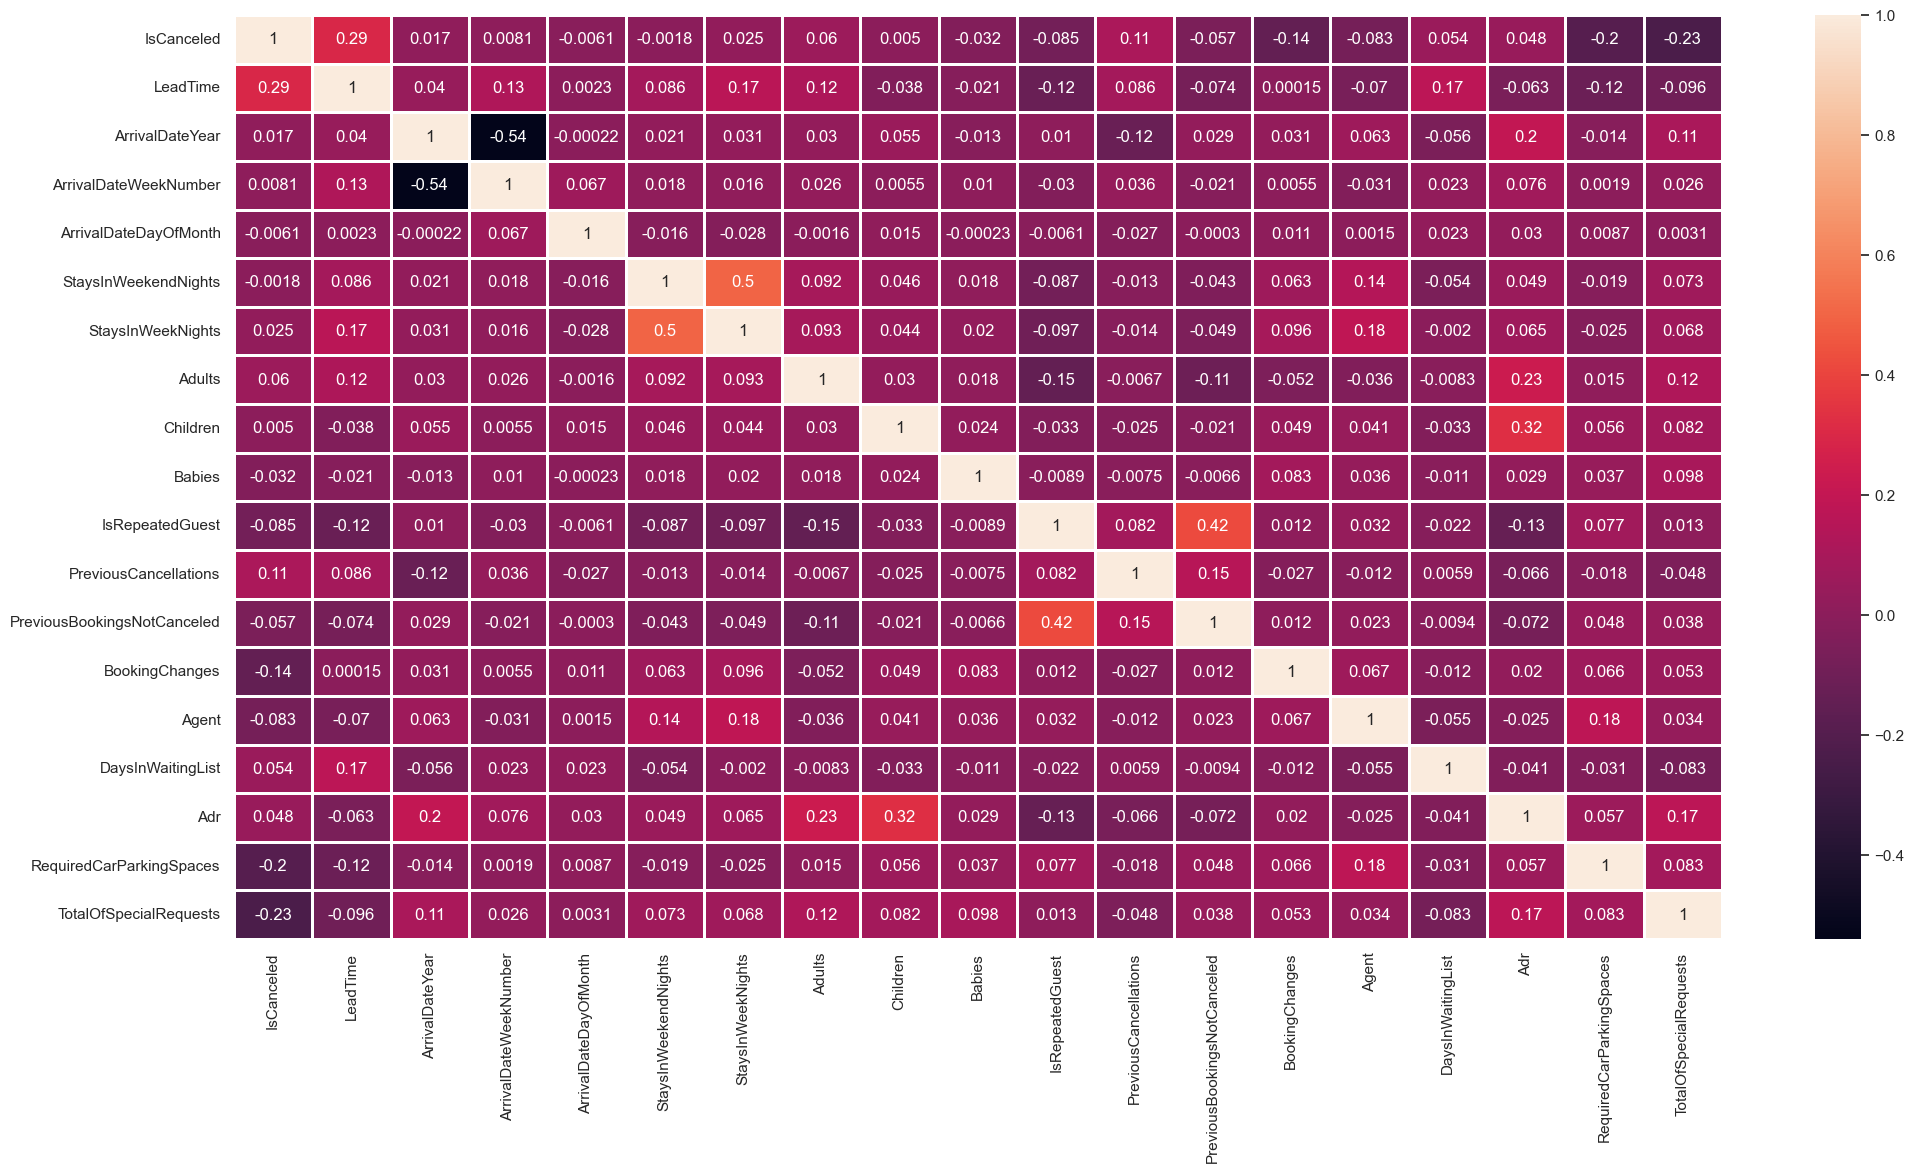

In [122]:
plt.figure(figsize = (24, 12))

corr = df_default.select_dtypes(include='number').corr()
sns.heatmap(corr, annot = True, linewidths = 1)
plt.show()

In [123]:
#start feature engineering
num_features = [
    "LeadTime",
    "StaysInWeekendNights",
    "StaysInWeekNights",
    "Adults",
    "Children",
    "Babies",
    "IsRepeatedGuest",
    "PreviousCancellations",
    "PreviousBookingsNotCanceled",
    "RequiredCarParkingSpaces",
    "TotalOfSpecialRequests",
    "Adr"]

cat_features = [
    "Hotel",
    "ArrivalDateMonth",
    "Meal",
    "MarketSegment",
    "DistributionChannel",
    "ReservedRoomType",
    "DepositType",
    "CustomerType"]

df_num = df_default[num_features]
df_cat = df_default[cat_features]
target= df_default.IsCanceled

In [124]:
df_num.head()

,LeadTime,StaysInWeekendNights,StaysInWeekNights,Adults,Children,Babies,IsRepeatedGuest,PreviousCancellations,PreviousBookingsNotCanceled,RequiredCarParkingSpaces,TotalOfSpecialRequests,Adr
0,342,0,0,2,0.0,0,0,0,0,0,0,0.0
75559,257,0,2,1,0.0,0,0,0,0,0,0,80.0
75560,257,0,2,2,0.0,0,0,0,0,0,0,101.5
75561,257,0,2,2,0.0,0,0,0,0,0,0,101.5
75562,257,0,2,2,0.0,0,0,0,0,0,0,101.5


In [125]:
df_cat.head()

,Hotel,ArrivalDateMonth,Meal,MarketSegment,DistributionChannel,ReservedRoomType,DepositType,CustomerType
0,Resort Hotel,July,BB,Direct,Direct,C,No Deposit,Transient
75559,City Hotel,July,HB,Offline TA/TO,TA/TO,A,No Deposit,Transient
75560,City Hotel,July,HB,Offline TA/TO,TA/TO,A,No Deposit,Transient
75561,City Hotel,July,HB,Offline TA/TO,TA/TO,A,No Deposit,Transient
75562,City Hotel,July,HB,Offline TA/TO,TA/TO,A,No Deposit,Transient


In [126]:
print('Unique Values per categorical feature:\n')
for feature in df_cat.columns:
    print(f'{'-'*170}\nColumn {feature}\'s unique values: {' | '.join(list(df_cat[feature].astype(str).unique()))}')
print('-'*170)

Unique Values per categorical feature:

--------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Column Hotel's unique values: Resort Hotel | City Hotel
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Column ArrivalDateMonth's unique values: July | August | September | October | November | December | January | February | March | April | May | June
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Column Meal's unique values: BB | HB | FB | SC | Undefined
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Column Marke

In [129]:
#building pipelines

#categorical pipeline
cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore"))
])

#numeric pipeline
num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

#column transformer
preprocessor = ColumnTransformer([
    ("num", num_pipe, num_features),
    ("cat", cat_pipe, cat_features)
])

#full pipeline
model = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(max_iter=1000))
])